
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



# Punto 1

In [26]:
import numpy as np
torgersen =  df[df.isla == "Torgersen"]
torgersen["profundidad_pico (mm)"].apply(lambda x: float(x))

min_pico = np.min(torgersen["profundidad_pico (mm)"])
max_pico = np.max(torgersen["profundidad_pico (mm)"])

print(f"Mínimo: {min_pico}, Máximo: {max_pico}")

Mínimo: 15.9, Máximo: 21.5


# Punto 2

In [32]:
df.loc[
    np.argmax(df["masa_corporal (g)"])
][["isla", "especie", "genero"]]

isla       Biscoe
especie    Gentoo
genero       Male
Name: 231, dtype: object

# Punto 3

In [60]:
machos_no_gentoo = df[
    (df["especie"] != "Gentoo") &
    (df["genero"] == "Male")
]

masa_media = np.mean(machos_no_gentoo["masa_corporal (g)"])

print(f"Masa media: {masa_media}")

Masa media: 4010.2803738317757


# Punto 4

Text(0.5, 1.0, 'Longitud media: 43.99; Desviación estándar: 5.46')

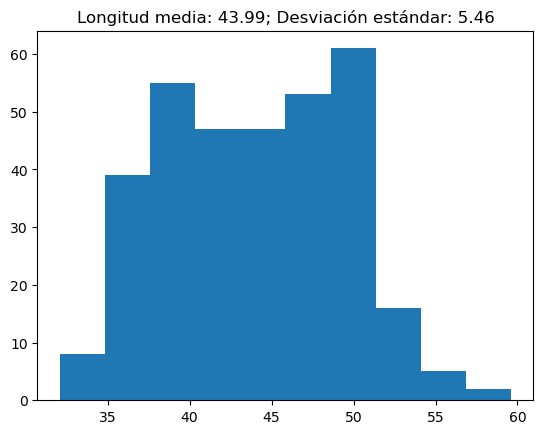

In [ ]:
import matplotlib.pyplot as plt

media = np.mean(df["longitud_pico (mm)"])
desviacion = np.std(df["longitud_pico (mm)"])

plt.hist(df["longitud_pico (mm)"])

plt.title(f"Longitud media: {media:.2f}; Desviación estándar: {desviacion:.2f}")

# Punto 5

In [80]:
print("Especies que aparecen")
df["especie"].value_counts()

Especies que aparecen


especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [81]:
print("Islas que aparecen")
df["isla"].value_counts()

Islas que aparecen


isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

<Axes: >

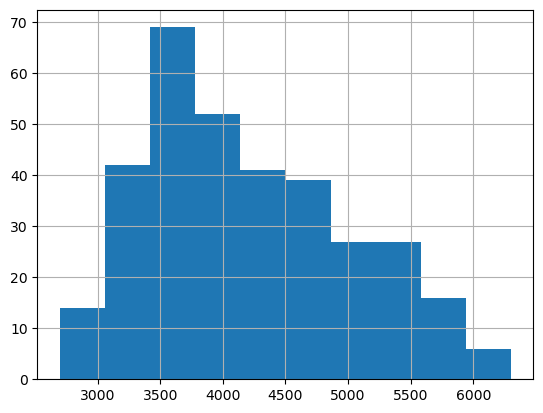

In [82]:
df["masa_corporal (g)"].hist()